In [1]:
from arcs.generate import GraphGenerator
from importlib import resources
import copy 

In [2]:
gg = GraphGenerator()
tabledict = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=298,
    pressure=40,
    max_reaction_length=4,
    graph=False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:537: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [3]:
import pandas as pd 
df = pd.DataFrame(tabledict)

In [4]:
from collections import defaultdict 
def table_refactor(tabledict):
    refactored_dict = defaultdict(dict)
    for i, _dict in tabledict.items():
        gibbs_free_energy = _dict["G"]
        if gibbs_free_energy < 0: 
            reactants = _dict["reactants"]
            products = _dict["products"]
            refactored_dict[i]["K"] = _dict["K"]
            refactored_dict[i]["G"] = _dict["G"]
            for compound,num in reactants.items():
                refactored_dict[i][compound] = -num # -ve as being removed 
            for compound,num in products.items():
                refactored_dict[i][compound] = num # +ve as being made
        else:
            reactants = _dict["products"]
            products = _dict["reactants"]
            refactored_dict[i]["K"] = _dict["K_rev"]
            refactored_dict[i]["G"] = _dict["G_rev"]
            for compound,num in reactants.items():
                refactored_dict[i][compound] = -num # -ve as being removed 
            for compound,num in products.items():
                refactored_dict[i][compound] = num # +ve as being made
    return refactored_dict 

refactor = table_refactor(tabledict)

In [5]:
refactored_df = pd.DataFrame(refactor)

In [6]:
import numpy as np 

In [7]:
# 1. get weighted random_compounds 
concs = {'H2O':50,'SO2':1,'NO2':9,'NO':13,"O2":73}
updated_concs = concs 
# convert to probabilities 
p_1 = {k: v / sum(concs.values()) for k, v in concs.items()}
p_1

{'H2O': 0.3424657534246575,
 'SO2': 0.00684931506849315,
 'NO2': 0.06164383561643835,
 'NO': 0.08904109589041095,
 'O2': 0.5}

In [8]:
# 2. weighted shuffle random 
#keys, weights = list(p_1.keys()), list(p_1.values())
#order = np.random.choice(keys, size=len(keys), replace=False, p=weights)
#reordered = {k: p_1[k] for k in order}#

#weighted_shuffle(p_1)a

### based on claude help 

1. find based on availability 
2. based on Gibbs 
3. based on extra availability i.e. 50% O2 means reactions with more stoichiometric O2 will be better 

In [9]:
import numpy as np
import pandas as pd

def table_rank_reactions(_concentrations, refactored_dict):
    concentrations = copy.deepcopy(_concentrations)
    probabilities = {k: v / sum(concentrations.values())
                     for k, v in concentrations.items()}

    df = pd.DataFrame(refactored_df).T.fillna(0)

    species = [c for c in df.columns if c not in ["G", "K"]]
    avail = np.array([probabilities.get(s, 0.0) for s in species])
    present = avail > 0

    # needs a different naming convention as S is entropy
    S = df[species].to_numpy(float)
    gibbs = df['G'].to_numpy(float)

    reac = np.clip(-S, 0, None)    # reactants: negative coeffs -> positive amounts
    prod = np.clip( S, 0, None)    # products:  positive coeffs

    # --- Criterion 4: EVERY reactant must be present ---
    reac_mask = reac > 0
    have_all  = ((reac_mask & ~present).sum(axis=1) == 0) & reac_mask.any(axis=1)    

    # --- Criteria 2 & 3: reactant availability, weighted by stoichiometry ---
    availability = reac @ avail    

    def minmax(x):
        lo, hi = np.nanmin(x), np.nanmax(x)
        return np.zeros_like(x) if hi == lo else (x - lo) / (hi - lo)    

    gibbs_term = 1 - minmax(gibbs)   # most negative -> ~1
    avail_term = minmax(availability)
    w_gibbs, w_avail = 0.3, 0.7
    score = w_gibbs * gibbs_term + w_avail * avail_term    

    def side(a):
        return " + ".join(f"{v:g} {s}" for s, v in zip(species, a) if v > 0)
    eqn = [f"{side(reac[i])} = {side(prod[i])}" for i in range(len(df))]    

    out = df.assign(reaction=eqn, availability=availability, score=score)
    ranked = out.loc[have_all].sort_values('score', ascending=False)    

    # --- guardrail: no reaction with a missing reactant may survive ---
    assert ((reac[have_all] > 0) & ~present).sum() == 0, "infeasible reaction leaked into ranked!"

    return ranked 


ranked = table_rank_reactions(updated_concs,refactor)

ranked.head(20)

,K,G,O3,O2,CH2O,CH3COOH,N2O2,NO,N2O4,NO2,...,CH3NH2,H2SO3,C2H5NH2,NOHSO4,CS2,CH3_C6H5,CH3_CO_CH3,reaction,availability,score
469,7.932541e+70,-4.192253,0.0,-3.0,0.0,0.0,0.0,-4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3 O2 + 4 NO + 2 H2O = 4 HNO3,2.541096,0.114353
1353,2.417644e+32,-1.914817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10 NO2 + 4 H2O = 1 N2 + 8 HNO3,1.986301,0.087258
1855,2.016138e+88,-5.221410,0.0,0.0,0.0,0.0,0.0,-10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10 NO + 2 H2O = 3 N2 + 4 HNO3,1.575342,0.074989
358,4.137329e+18,-1.100799,0.0,-1.0,0.0,0.0,0.0,-4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 4 NO + 2 H2O = 4 HNO2,1.541096,0.067099
1456,1.364332e+08,-0.481014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8 NO2 + 3 H2O = 1 N2O + 6 HNO3,1.520548,0.065259
542,6.494689e+24,-1.467156,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,-4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 4 NO2 + 2 H2O = 4 HNO3,1.431507,0.063022
445,3.328788e+41,-2.455196,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 H2O + 2 SO2 = 2 H2SO4,1.198630,0.054686
1679,2.620732e+24,-1.443851,0.0,0.0,0.0,0.0,0.0,-6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6 NO + 2 H2O = 1 N2 + 4 HNO2,1.219178,0.053978
1399,2.129291e+17,-1.024611,0.0,0.0,0.0,0.0,0.0,-8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8 NO + 1 H2O = 3 N2O + 2 HNO3,1.054795,0.046349
28,1.105165e+23,-1.362548,0.0,-1.0,0.0,0.0,0.0,-2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 NO = 2 NO2,0.678082,0.030895


In [10]:
import numpy as np
import pandas as pd


def table_rank_reactions_2(_concentrations, refactored_dict):
    concentrations = copy.deepcopy(_concentrations)
    probabilities = {k: v / sum(concentrations.values())
                     for k, v in concentrations.items()}

    df = pd.DataFrame(refactored_df).T.fillna(0)

    species = [c for c in df.columns if c not in ["G", "K"]]
    avail = np.array([probabilities.get(s, 0.0) for s in species])
    present = avail > 0

    S     = df[species].to_numpy(float)
    gibbs = df['G'].to_numpy(float)    

    reac = np.clip(-S, 0, None)
    prod = np.clip( S, 0, None)    

    # --- Criterion 4: EVERY reactant must be present ---
    reac_mask = reac > 0
    have_all  = ((reac_mask & ~present).sum(axis=1) == 0) & reac_mask.any(axis=1)    

    # --- Criteria 2 & 3: reactant availability, weighted by stoichiometry ---
    availability = reac @ avail    

    def minmax(x):
        lo, hi = np.nanmin(x), np.nanmax(x)
        return np.zeros_like(x) if hi == lo else (x - lo) / (hi - lo)    

    # --- Criterion 1: Gibbs (most negative -> best) ---
    gibbs_term = 1 - minmax(gibbs)    

    # --- Criterion 5 (Occam): fewer/smaller coefficients -> simpler ---
    complexity  = np.abs(S).sum(axis=1)      # total molecules, both sides
    simple_term = 1 - minmax(np.log1p(complexity))   # log dampens huge outliers    

    w_gibbs, w_avail, w_simple = 0.25, 0.45, 0.30    # <- three-way priority knob
    score = (w_gibbs * gibbs_term +
             w_avail * minmax(availability) +
             w_simple * simple_term)    

    def side(a):
        return " + ".join(f"{v:g} {s}" for s, v in zip(species, a) if v > 0)
    eqn = [f"{side(reac[i])} = {side(prod[i])}" for i in range(len(df))]    

    out = df.assign(reaction=eqn, availability=availability,
                    complexity=complexity, score=score)
    ranked = out.loc[have_all].sort_values('score', ascending=False)    

    assert ((reac[have_all] > 0) & ~present).sum() == 0, "infeasible reaction leaked into ranked!"

    return ranked 

ranked = table_rank_reactions_2(updated_concs,refactor)

ranked.head(20)

,K,G,O3,O2,CH2O,CH3COOH,N2O2,NO,N2O4,NO2,...,H2SO3,C2H5NH2,NOHSO4,CS2,CH3_C6H5,CH3_CO_CH3,reaction,availability,complexity,score
145,1.944312e+03,-0.194463,0.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 1 NO = 1 NO3,0.589041,3.0,0.316318
5,9.030900e+18,-1.120845,0.0,-1.0,0.0,0.0,0.0,-2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 NO = 1 N2O4,0.678082,4.0,0.301047
10,6.334358e+05,-0.343052,0.0,1.0,0.0,0.0,0.0,-2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2 NO = 1 O2 + 1 N2,0.178082,4.0,0.286398
28,1.105165e+23,-1.362548,0.0,-1.0,0.0,0.0,0.0,-2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 NO = 2 NO2,0.678082,5.0,0.285914
170,3.111191e+18,-1.093479,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 SO2 = 2 SO3,0.513699,5.0,0.281081
445,3.328788e+41,-2.455196,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1 O2 + 2 H2O + 2 SO2 = 2 H2SO4,1.198630,7.0,0.277160
155,1.231597e+09,-0.537516,0.0,0.0,0.0,0.0,0.0,-3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3 NO = 1 N2 + 1 NO3,0.267123,5.0,0.273632
179,3.028469e+05,-0.324102,0.0,0.0,0.0,0.0,0.0,-3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3 NO = 1 NO2 + 1 N2O,0.267123,5.0,0.273355
1915,1.606841e+03,-0.189568,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2 NO + 1 SO2 = 1 N2O + 1 SO3,0.184932,5.0,0.270938
469,7.932541e+70,-4.192253,0.0,-3.0,0.0,0.0,0.0,-4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3 O2 + 4 NO + 2 H2O = 4 HNO3,2.541096,13.0,0.268622


### Todo 

1. figure out next stage of algorithm

    a) continue as normal ARCS algorithm:

        - random weighted choice of reaction
        - proceed down a random path 


    b) new algorithm:

        - randomly sample i.e. 1k times the ranked reactions here 
        - update concentrations 
        - generate a new ranked table, and sample that 1k times 
        - update concentrations 
        - do this N times until "converged" (if it does converge?)


    c) alternative new algorithm 

        - run all the top 20 ranked reactions 
        - update concentrations 
        - do it again 
        - etc. 
        - (make sure to randomly order the reactions each time)

### scenario 1 : continue as normal ARCS algorithm 

In [11]:
from chempy.equilibria import Equilibrium, EqSystem
from chempy import Substance
import itertools as it 
import warnings 
import copy 

def choose_reaction(ranked_reactions: dict) -> int:
    """
    given a dictionary of ranked reactions from self.get_weighted_reaction_rankings
    chose a reaction based on weights and probabilities
    """
   #weights = {
   #     k: v["score"] for k, v in ranked_reactions.items()
   # }  # here higher is better
    weights = {k:1/v**2 for k,v in ranked_reactions["score"].items()}
    # added a square multiplier to force more the larger coefficients
    probabilities = {k: v / sum(weights.values())
                     for k, v in weights.items()}
    chosen_reaction = np.random.choice(
        [
            np.random.choice(
                a=list(probabilities.keys()),
                size=len(probabilities) * 10,
                p=list(probabilities.values()),
            )
        ][0]
    )
    return chosen_reaction

def generate_chempy_eqsystem(tabledict, index: int) -> EqSystem:
    """
    given a reaction index form a chempy.equilibria.EqSystem

    eventually this will be deprecated as it is a speed bottleneck

    needs to involve charged species

    """
    node_dict = tabledict[index]
    reactants = node_dict["reactants"]
    products = node_dict["products"]
    k = node_dict["K"]

    substances = {}
    for compound in list(it.chain(*[list(reactants) + list(products)])):
        substances[compound] = Substance.from_formula(
            compound, **{"charge": 0})

    equation = Equilibrium(reac=reactants, prod=products, param=k)
    try:
        return EqSystem([equation], substances=substances)
    except Exception:
        return None
    
def chempy_equilibrium_concentrations(
     concentrations: dict,
     equilibrium_reaction: EqSystem,
     chempy_sane=True,
 ) -> dict:
     """
     generate equilibrium concentrations
     if the reaction is "sane" and a "success" then it returns the equilibrium concentrations as a dict of concentrations
     elsewise
     return None
     """

     warnings.simplefilter("ignore")
     _concs = copy.deepcopy(concentrations)
     try:
         result = equilibrium_reaction.solve(init_concs=_concs)
         # assert result.success and result.sane
         if chempy_sane:
             assert result.success and result.sane
         else:
             assert result.success
         for compound, concentration in enumerate(result.conc):
             _concs[equilibrium_reaction.substance_names()[compound]
                    ] = concentration
         return _concs
     except Exception:
         return None

In [12]:
###make chempy friendly concentrations dictionary 
species = [c for c in ranked.columns if c not in ["G","K"]]
updated_concs = defaultdict(dict)
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 


In [13]:
### rank the reactions 
ranked_reactions = ranked.head(20)
chosen_reaction = choose_reaction(ranked_reactions.to_dict())

In [14]:
### generate an chempy eqsystem 
eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
eqsystem 

In [15]:
#generate updated concentrations 
new_concentrations = chempy_equilibrium_concentrations(concentrations=updated_concs,
                                  equilibrium_reaction=eqsystem,
                                  chempy_sane=True)
new_concentrations

defaultdict(dict,
            {'O3': 0,
             'O2': 73,
             'CH2O': 0,
             'CH3COOH': 0,
             'N2O2': 0,
             'NO': np.float64(1.1656904882267386e-06),
             'N2O4': np.float64(3.249999708577378),
             'NO2': 9,
             'HCOOH': 0,
             'CH3CHO': 0,
             'H2CO3': 0,
             'N2': np.float64(3.249999708577378),
             'NO3': 0,
             'N2O': 0,
             'CH4': 0,
             'CH3OH': 0,
             'C2H5OH': 0,
             'CO2': 0,
             'C2H6O2': 0,
             'H2O': 50,
             'CO': 0,
             'HCN': 0,
             'C6H6': 0,
             'H2O2': 0,
             'HNO2': 0,
             'SO2': 1,
             'SO3': 0,
             'H2S': 0,
             'H2SO4': 0,
             'H2': 0,
             'C3H7NH2': 0,
             'NH3': 0,
             'C4H9NH2': 0,
             'S8': 0,
             'COS': 0,
             'HNO3': 0,
             'CH3NH2': 0,
        

In [40]:
###make chempy friendly concentrations dictionary 
concs = {"H2O":50,"SO2":1,"NO2":11,"NO":12,"O2":100}
species = [c for c in ranked.columns if c not in ["G","K"]]
updated_concs = {}
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 


In [54]:
# production run 
import tqdm 

def runner(updated_concs):
    reactionstats = {0:None}
    concentrations = {0:updated_concs}
    i=0
    for step in tqdm.tqdm(range(1,100)):
        _concentrations = copy.deepcopy(concentrations[i])
        ranked_reactions = table_rank_reactions_2(_concentrations,refactor).head(20)
        chosen_reaction = choose_reaction(ranked_reactions.to_dict())
        eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
        new_concentrations = chempy_equilibrium_concentrations(concentrations=_concentrations,
                                      equilibrium_reaction=eqsystem,
                                      chempy_sane=True)
        
        if new_concentrations: 
            i+=1 
            concentrations[i] = new_concentrations
            reactionstats[i] = {
                    "reaction":tabledict[chosen_reaction]["rstring"],
                    #"equilibrium_constant":tabledict[chosen_reaction]["K"]
            }
    return concentrations,reactionstats

concentrations,reactionstats = runner(updated_concs)

100%|██████████| 99/99 [00:03<00:00, 26.70it/s]


In [55]:
from collections import Counter
pd.Series(Counter([x["reaction"] for x in reactionstats.values() if not x == None])).sort_values(ascending=False)

1 HNO3 + 1 SO2 = 1 NOHSO4               9
1 H2O + 1 N2O4 = 1 HNO3 + 1 HNO2        5
1 N2O + 1 HNO2 = 1 HNO3 + 1 N2          5
1 HNO3 + 1 NO = 1 HNO2 + 1 NO2          4
1 H2SO4 + 1 N2O4 = 1 HNO3 + 1 NOHSO4    4
3 O2 + 2 N2O = 2 N2O4                   4
1 O2 + 2 NO = 2 NO2                     4
1 HNO2 + 1 SO3 = 1 NOHSO4               4
1 H2O + 1 O2 + 1 N2O = 2 HNO2           4
1 N2O + 1 SO2 = 1 N2 + 1 SO3            4
1 H2O + 1 NOHSO4 = 1 H2SO4 + 1 HNO2     3
1 NO2 + 1 SO2 = 1 NO + 1 SO3            3
1 O2 + 2 NO = 1 N2O4                    3
2 O2 + 1 N2 = 2 NO2                     2
2 O2 + 1 N2 = 1 N2O4                    2
1 O2 + 1 N2 = 2 NO                      2
1 N2O4 = 1 NO3 + 1 NO                   2
1 N2O4 = 2 NO2                          2
1 H2O + 1 SO3 = 1 H2SO4                 2
1 HNO3 + 1 SO2 = 1 HNO2 + 1 SO3         1
1 N2O + 1 NO2 = 3 NO                    1
1 H2O + 2 O2 + 1 N2O = 2 HNO3           1
1 H2SO4 + 1 N2O4 = 2 HNO3 + 1 SO2       1
1 O2 + 2 SO2 = 2 SO3              

<Axes: >

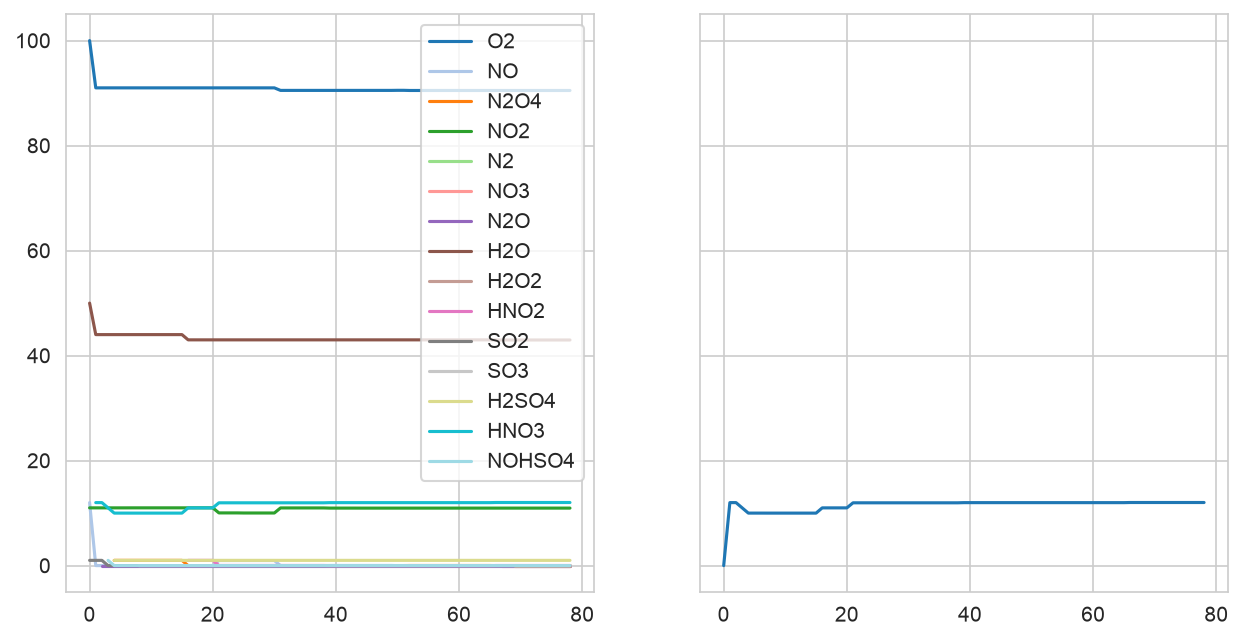

In [56]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.set_style("whitegrid")
fig,ax = plt.subplots(ncols=2,figsize=(10,5),dpi=150,sharey=True,sharex=True)

concdf = pd.DataFrame(concentrations)
concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=ax[0],cmap="tab20")
concdf.T["HNO3"].plot.line(ax=ax[1],cmap="tab20")
#ax[0].set_xscale("log")
#ax[0].set_xlim(0,5)

In [20]:
pd.DataFrame(reactionstats).T

,reaction
0,None
1,1 H2S + 3 NO2 = 1 H2SO3 + 3 NO
2,1 H2SO4 + 1 NO = 1 H2SO3 + 1 NO2
3,2 NO2 + 1 N2 = 4 NO
4,1 N2O + 1 NO2 = 3 NO
5,1 N2O + 3 H2SO4 = 3 H2SO3 + 2 NO2
6,1 NO3 + 1 N2 = 3 NO
7,1 N2O2 + 1 H2SO4 = 1 H2S + 2 NO3
8,1 N2O2 = 1 O2 + 1 N2
9,1 O2 + 1 NO = 1 NO3
